In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_excel("youtube_data.xlsx")

In [3]:
# 1. Dataset yarat
print("Head\n",df.head())

Head
   Video_ID  Likes  Comments  Views
0  VID_001    152        68   9661
1  VID_002    485       135  22641
2  VID_003    910        55  27413
3  VID_004    320       139  18807
4  VID_005    156        25   5779


In [4]:
#  2. Data Analizi
print("Describe\n",df[["Likes","Comments","Views"]].describe())
print()
print("Correlation\n",df[["Likes","Comments","Views"]].corr())

Describe
             Likes    Comments         Views
count   50.000000   50.000000     50.000000
mean   481.120000   91.840000  19329.700000
std    260.274003   58.061319   8808.743252
min     70.000000    6.000000   2115.000000
25%    246.750000   49.000000  12152.500000
50%    496.500000   87.000000  18714.500000
75%    712.500000  136.000000  25858.000000
max    925.000000  195.000000  35918.000000

Correlation
              Likes  Comments     Views
Likes     1.000000  0.230622  0.863714
Comments  0.230622  1.000000  0.688569
Views     0.863714  0.688569  1.000000


In [5]:
# 3. Regression qur (Scikit-Learn ilə)
X = df[["Likes","Comments"]]
Y = df["Views"]

model = LinearRegression()
model.fit(X,Y)

print('Regression neticeleri')
print('Likes coefficient:',model.coef_[0])
print('Comments coefficient:',model.coef_[1])
print('Intercept:',model.intercept_)

Regression neticeleri
Likes coefficient: 25.197385329050068
Comments coefficient: 78.4164171956595
Intercept: 4.970215238063247


In [6]:
# 4. Öz Gradient Descent versiyanı yaz
x = df["Likes"].values
y = df["Views"].values

x = (x - x.mean()) / x.std()

m = 0
b = 0

L = 0.0001
epochs = 1000

n = len(x)

errors = []

for epoch in range(epochs):

    y_pred = m * x + b

    error = np.mean((y - y_pred) ** 2)
    errors.append(error)

    D_m = (-2 / n) * np.sum(x * (y - y_pred))
    D_b = (-2 / n) * np.sum(y - y_pred)

    m -= L * D_m
    b -= L * D_b

    if epoch % 100 == 0:
        print(f"Epoch {epoch} Error = {error:.2f}")

print("\nGradient Descent neticesi")
print("m =", m)
print("b =", b)

Epoch 0 Error = 449679380.62
Epoch 100 Error = 432802879.19
Epoch 200 Error = 416588179.71
Epoch 300 Error = 401009330.02
Epoch 400 Error = 386041395.64
Epoch 500 Error = 371660419.90
Epoch 600 Error = 357843385.55
Epoch 700 Error = 344568177.98
Epoch 800 Error = 331813549.77
Epoch 900 Error = 319559086.71

Gradient Descent neticesi
m = 1365.401518983377
b = 3504.196717667813


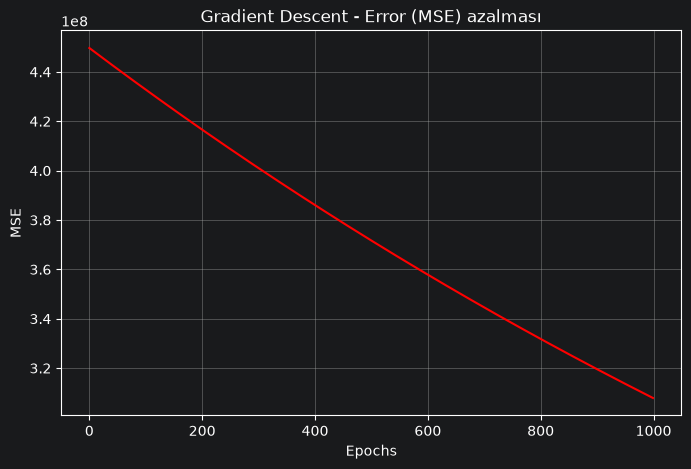

In [7]:
#  5. Error qrafiki
plt.figure(figsize=(8,5))
plt.plot(errors,color="red")
plt.title("Gradient Descent - Error (MSE) azalması")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

In [19]:
# 6. Təxmin et
like = 350
comment = 40

prediction = model.predict(np.array([[like, comment]]))

print(f"Texmin edilen Views: {prediction[0]:.0f}")

Texmin edilen Views: 11961


C:\Users\LOQ\Desktop\Python_AI-Practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
y_pred = model.predict(X)

mae = mean_absolute_error(y,y_pred)
mse = mean_squared_error(y,y_pred)
r2 = r2_score(y,y_pred)

print('Model Matrikleri\n')
print("MAE:",mae)
print("MSE:",mse)
print("R2:",r2)

Model Matrikleri

MAE: 246.633006419004
MSE: 80140.60853180349
R2: 0.9989461018151918
